In [1]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [2]:
from boulder_statistics.analysis.log_normal_fitting import LogNormalFitting
from boulder_statistics.analysis.sensitivity_model.KDE_bootstrapped_sensitivity_model import KDEBootstrappedSensitivityModel

sm = KDEBootstrappedSensitivityModel(dp.db_jaccard_agg)
fit = LogNormalFitting(dp, LAD_min=0, sensitivity_model = sm)

In [3]:
from pickle import FALSE

from statsmodels.base.model import GenericLikelihoodModelResults
from boulder_statistics.analysis.fit_params.log_normal_fit_params import LogNormalFitParams

mle_model: GenericLikelihoodModelResults = fit.MLE_fit(
    optimize_params = LogNormalFitParams(mu=-2.302585093, sigma=2),
    verbose = False
)

                              TheoryFit Results                               
Dep. Variable:                      y   Log-Likelihood:            -2.5518e+06
Model:                      TheoryFit   AIC:                         5.104e+06
Method:            Maximum Likelihood   BIC:                         5.104e+06
Date:                Fri, 03 Jul 2026                                         
Time:                        13:10:30                                         
No. Observations:              412506                                         
Df Residuals:                  412504                                         
Df Model:                           2                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
par0          -4.9203      0.034   -144.990      0.000      -4.987      -4.854
par1           2.1505      0.010    225.518      0.0

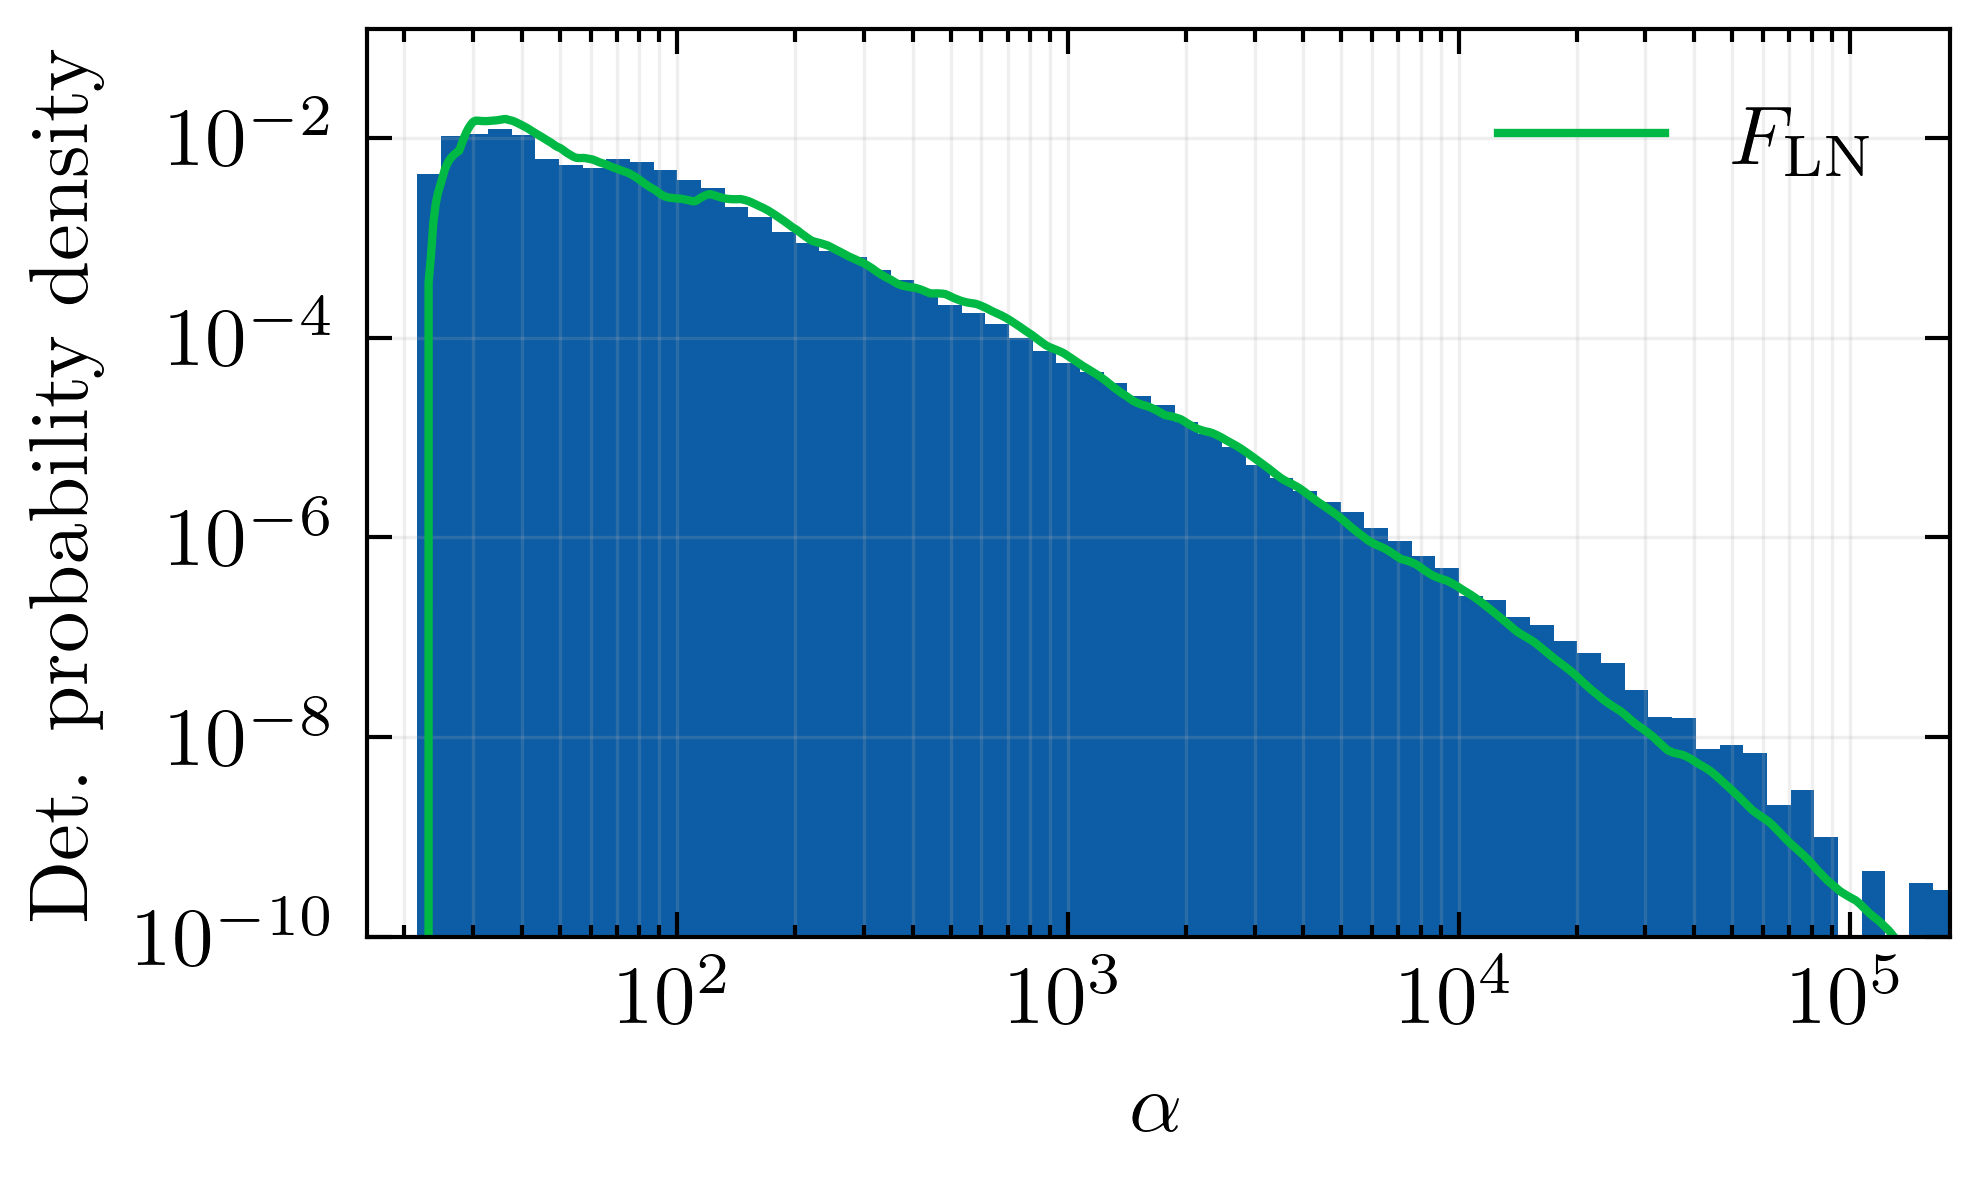

In [4]:
alphas_hist = np.geomspace(1, 1e6, 100)
alphas = np.geomspace(1, 1e6, 1000)

counts, bins, _ = plt.hist(fit.cleaned_alphas_best_S,
                           alphas_hist, density = True)

fit_params = LogNormalFitParams(*mle_model.params)
plt.plot(alphas, fit.F_norm(alphas, fit_params, sm.best_S_function), label = r"$F_{\text{LN}}$")

plt.ylim(1e-10, counts.max() * 10)
plt.xlim(fit.plot_range[0] * 0.7, fit.plot_range[1] * 0.5)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
plt.show()

In [5]:
from datetime import datetime

output_dir = Path("MLE_random_sample_fit_data/LogNormal")

while True:
    df = fit.MultiMLEFit(
        optimize_params=LogNormalFitParams(mu=-5, sigma=2),
        numb_runs=20,
        summary = False
    )

    # Filename based on current datetime (to the second)
    timestamp: str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    filename: Path = output_dir / f"{timestamp}.parquet"
    filename.parent.mkdir(parents=True, exist_ok=True)

    df.write_parquet(filename)

    print(f"Saved {filename}")

MultiMLE fit running:  80%|████████  | 16/20 [06:19<01:34, 23.74s/it]


KeyboardInterrupt: 